In [3]:
import torch 
device = 'mps' if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
device

'mps'

In [ ]:
import os
import kagglehub
import requests
from pathlib import Path
import shutil

sentiment_destination_folder = Path("./Kaggle_data")
sentiment_destination_folder.mkdir(parents=True, exist_ok=True)

print("Downloading emotion dataset")
cache_path = kagglehub.dataset_download("shivamb/go-emotions-google-emotions-dataset")
cache_dir = Path(cache_path)
for item in cache_dir.iterdir():
    target_path = sentiment_destination_folder / item.name
    if target_path.exists():
        if target_path.is_dir():
            shutil.rmtree(target_path)
        else:
            os.remove(target_path)
    shutil.move(str(item), str(target_path))


tokenizer_file_path = 'tokenizer.py'
with open(tokenizer_file_path , 'wb') as f:
    response = requests.get("https://raw.githubusercontent.com/hartej46/Tokenizer/refs/heads/main/regextokenizer.py")
    f.write(response.content)

print("Path to dataset files:", sentiment_destination_folder)

Path to dataset files: Kaggle_data


In [5]:
import pandas as pd
df = pd.read_csv(sentiment_destination_folder/'go_emotions_dataset.csv')

df.head()

,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eew5j0j,That game hurt.,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,eemcysk,>sexuality shouldn’t be a grouping category I...,True,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ed2mah1,"You do right, if you don't care then fuck 'em!",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,eeibobj,Man I love reddit.,False,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,eda6yn6,"[NAME] was nowhere near them, he was by the Fa...",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [6]:
emotion_cols = df.columns[3:]
df['sentiment_name'] = df[emotion_cols].idxmax(axis=1)

df[['text', 'sentiment_name']].head()

,text,sentiment_name
0,That game hurt.,sadness
1,>sexuality shouldn’t be a grouping category I...,admiration
2,"You do right, if you don't care then fuck 'em!",neutral
3,Man I love reddit.,love
4,"[NAME] was nowhere near them, he was by the Fa...",neutral


In [7]:
from torch.utils.data import Dataset

class TextFolder(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.tokenizer = tokenizer
        self.emotion_cols = list(data.columns[3:31]) 

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        text = str(row['text'])

        labels = row[self.emotion_cols].values.astype('float32')
        tokens = self.tokenizer.encode(text)

        return torch.tensor(tokens, dtype=torch.long) , torch.tensor(labels)

    def num_classes(self):
        return len(self.data.iloc[0,3:31])

In [8]:
from tokenizer import RegexTokenizer
tokenizer = RegexTokenizer()

In [9]:
train_text = " ".join(df['text'].sample(n=100000, random_state=42).astype(str).tolist())


In [10]:
# tokenizer.train(text=train_text, vocab_size=6000, debug=True)

In [11]:
vocab_size = 10000
model_file = Path('./sentiment.model')
if model_file.exists():
    tokenizer.load(str(model_file))
else:
    tokenizer.train(text=train_text, vocab_size=vocab_size, debug=True)
    tokenizer.save('sentiment')

In [12]:
import sklearn
from sklearn.model_selection import train_test_split

train_split, test_split = train_test_split(df, test_size=0.2, random_state=42)
len(train_split), len(test_split)

(168980, 42245)

In [13]:
train_dataset = TextFolder(data=train_split, tokenizer=tokenizer)
test_dataset = TextFolder(data=test_split, tokenizer=tokenizer)

ids, labels = train_dataset[0]
ids, labels

(tensor([4827,  350,  300,  276,  644,  665, 1280,  437,  266, 4556,   32,  274,
          890,  105, 1333,  617,  368,  266, 6455, 3576,   46]),
 tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SentimentTrackerModel(nn.Module):
    def __init__(self, out_features, embedding_dim, hidden_dim, vocab_size, num_heads=4):
        super().__init__()
        
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim, padding_idx=0)
        self.embedding_dropout = nn.Dropout(p=0.2)
        self.conv = nn.Conv1d(
            in_channels=embedding_dim,
            out_channels=embedding_dim,
            kernel_size=3,
            padding=1
        )
        self.relu = nn.ReLU()
        self.attention = nn.MultiheadAttention(embed_dim=embedding_dim, num_heads=num_heads, batch_first=True)
        self.layer_norm = nn.LayerNorm(embedding_dim)
        
        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.fc1_dropout = nn.Dropout(p=0.4)
        self.fc2 = nn.Linear(hidden_dim, out_features)

    def forward(self, x):
        padding_mask = (x == 0)
        
        x = self.embedding(x)
        x = self.embedding_dropout(x)
        
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        x = self.relu(x)
        x = x.permute(0, 2, 1)
        
        attn_output, _ = self.attention(x, x, x, key_padding_mask=padding_mask)
        x = self.layer_norm(x + attn_output)  
        x = torch.mean(x, dim=1)
        
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc1_dropout(x)
        return self.fc2(x)

In [15]:
import torch
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

def train_step(model, dataloader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0
    batch_counter = 0
    all_preds = []
    all_trues = []

    for batch, (x, y) in enumerate(tqdm(dataloader, desc='This is training data')):
        x, y = x.to(device), y.to(device)

        y_pred = model(x)
        loss = loss_fn(y_pred, y)
        total_loss += loss.item()
        batch_counter += 1
        y_pred_probs = torch.sigmoid(y_pred)
        y_pred_class = (y_pred_probs >= 0.5).int().cpu().numpy()
        y_true = y.cpu().numpy()
        
        batch_f1 = f1_score(y_true, y_pred_class, average='micro', zero_division=0)
        all_preds.append(y_pred_class)
        all_trues.append(y_true)

        if batch_counter%400 == 0:
            print(f"Batch: {batch} / {len(dataloader.dataset)} Loss : {loss:.5f} || Test f1 : {batch_f1*100:.2f}%")
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

    epoch_preds = np.vstack(all_preds)
    epoch_trues = np.vstack(all_trues)
    global_test_f1 = f1_score(epoch_trues, epoch_preds, average='micro', zero_division=0)
        
    return total_loss / len(dataloader), global_test_f1

In [16]:
def test_step(
        model: torch.nn.Module,
        dataloader: torch.utils.data.DataLoader,
        loss_fn: torch.nn.Module,
        device: torch.device):

    test_loss = 0
    batch_counter = 0
    all_preds = []
    all_trues = []
    model.eval()
    with torch.inference_mode():
        for batch, (x,y) in enumerate(tqdm(dataloader, desc="Testing Batches", leave=False)):
            x,y = x.to(device), y.to(device)
            test_pred_logits = model(x)
            batch_counter += 1

            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            y_pred_probs = torch.sigmoid(test_pred_logits)
            y_pred_class = (y_pred_probs >= 0.5).int().cpu().numpy()
            y_true = y.cpu().numpy()
        
            batch_f1 = f1_score(y_true, y_pred_class, average='micro', zero_division=0)
            all_preds.append(y_pred_class)
            all_trues.append(y_true)

            if batch_counter%200 == 0:
                print(f"test_loss : {loss:.5f} || Test f1 : {batch_f1*100:.2f}%")

        test_loss = test_loss/len(dataloader)
        epoch_preds = np.vstack(all_preds)
        epoch_trues = np.vstack(all_trues)
        global_test_f1 = f1_score(epoch_trues, epoch_preds, average='micro', zero_division=0)

        return test_loss, global_test_f1

In [17]:
def eval_model(model: torch.nn.Module,
                dataloader: torch.utils.data.DataLoader,
                device: torch.device):
    results = []
    model.eval()
    with torch.inference_mode():
        for batch, (x,y) in enumerate(tqdm(dataloader, desc="Testing Batches", leave=False)):
            x,y = x.to(device), y.to(device)
            y_logits = model(x)
            y_pred = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)
            results.extend(y_pred.cpu().numpy())
        return results

In [18]:
def train(model: torch.nn.Module,
            train_dataloader: torch.utils.data.DataLoader,
            test_dataloader: torch.utils.data.DataLoader,
            optimizer: torch.optim.Optimizer,
            loss_fn: torch.nn.Module,
            scheduler,
            epochs: int = 5,
            device: torch.device = "cpu"):
    torch.manual_seed(42)
    torch.cuda.manual_seed(42)
    results = {"train_loss": [],
            "train_f1": [],
            "test_loss": [],
            "test_f1": []
        }

    for epoch in tqdm(range(epochs)):
        train_loss, train_f1 = train_step(model=model,
                                        dataloader=train_dataloader,
                                        loss_fn=loss_fn,
                                        optimizer=optimizer,
                                        device=device
                                        )
        test_loss, test_f1 = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn,
            device = device)
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_f1: {train_f1:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_f1: {test_f1:.4f}"
        )
        results["train_f1"].append(train_f1.item() if isinstance(train_f1, torch.Tensor) else train_f1)
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_f1"].append(test_f1.item() if isinstance(test_f1, torch.Tensor) else test_f1)
        scheduler.step(test_f1)

    return results

In [19]:
from torch.nn.utils.rnn import pad_sequence

def collate_batch(batch):
    label_list, text_list = [], []
    for (_text, _label) in batch:
        label_list.append(_label)
        text_list.append(_text)

    text_padded = pad_sequence(text_list, batch_first=True, padding_value=0)
    label_tensor = torch.stack(label_list).to(torch.float32)

    return text_padded, label_tensor

In [20]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset,batch_size=64,shuffle=True,collate_fn=collate_batch)
test_dataloader = DataLoader(test_dataset,batch_size=64,shuffle=False,collate_fn=collate_batch)

In [25]:
import numpy as np

all_labels = np.vstack([y.numpy() for _, y in train_dataset])
pos_counts = all_labels.sum(axis=0)
neg_counts = len(all_labels) - pos_counts

smooth_ratios = np.sqrt(neg_counts / (pos_counts + 1e-5))
pos_weight = torch.tensor(smooth_ratios, dtype=torch.float32).to(device)

model_1 = SentimentTrackerModel(
    out_features=train_dataset.num_classes(), 
    embedding_dim=256, 
    hidden_dim=256, 
    vocab_size=len(tokenizer.vocab)
).to(device)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    params=model_1.parameters(),
    lr=0.0008,
    weight_decay=0.05
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='max',   
    factor=0.5,
    patience=1,
)

In [27]:
from timeit import default_timer as timer
start_time = timer()
NUM_EPOCHS = 10

model_1_results = train(model=model_1,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS,
                        device=device,
                        scheduler = scheduler
                        )
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

This is training data:   0%|          | 0/2641 [00:00<?, ?it/s]

Batch: 399 / 168980 Loss : 0.47137 || Test f1 : 13.46%
Batch: 799 / 168980 Loss : 0.40933 || Test f1 : 20.00%
Batch: 1199 / 168980 Loss : 0.39408 || Test f1 : 32.81%
Batch: 1599 / 168980 Loss : 0.40175 || Test f1 : 19.35%
Batch: 1999 / 168980 Loss : 0.34781 || Test f1 : 35.48%
Batch: 2399 / 168980 Loss : 0.40613 || Test f1 : 24.79%


Testing Batches:   0%|          | 0/661 [00:00<?, ?it/s]

test_loss : 0.37566 || Test f1 : 31.01%
test_loss : 0.36176 || Test f1 : 26.87%
test_loss : 0.36376 || Test f1 : 42.25%
Epoch: 1 | train_loss: 0.4167 | train_f1: 0.2697 | test_loss: 0.3715 | test_f1: 0.3658


...

test_loss : 0.36696 || Test f1 : 41.86%
test_loss : 0.34752 || Test f1 : 36.99%
test_loss : 0.32341 || Test f1 : 46.06%
Epoch: 9 | train_loss: 0.3017 | train_f1: 0.4175 | test_loss: 0.3371 | test_f1: 0.4068


This is training data:   0%|          | 0/2641 [00:00<?, ?it/s]

Batch: 399 / 168980 Loss : 0.25498 || Test f1 : 48.41%
Batch: 799 / 168980 Loss : 0.28484 || Test f1 : 42.35%
Batch: 1199 / 168980 Loss : 0.25310 || Test f1 : 46.34%
Batch: 1599 / 168980 Loss : 0.32224 || Test f1 : 34.68%
Batch: 1999 / 168980 Loss : 0.30770 || Test f1 : 38.55%
Batch: 2399 / 168980 Loss : 0.30759 || Test f1 : 38.51%


Testing Batches:   0%|          | 0/661 [00:00<?, ?it/s]

test_loss : 0.37733 || Test f1 : 37.04%
test_loss : 0.35618 || Test f1 : 34.48%
test_loss : 0.31804 || Test f1 : 48.78%
Epoch: 10 | train_loss: 0.2960 | train_f1: 0.4215 | test_loss: 0.3400 | test_f1: 0.4060
Total training time: 1687.644 seconds


In [22]:
import matplotlib.pyplot as plt
from typing import Dict, List

In [28]:
def plot_loss_curves(results: Dict[str, List[float]]):
    """
        Plots training curves of a results dictionary.
    """

    loss = results['train_loss']
    test_loss = results['test_loss']
    accuracy = results['train_f1']
    test_accuracy = results['test_f1']
    epochs = range(len(results['train_loss']))

    plt.figure(figsize=(15, 7))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_f1')
    plt.plot(epochs, test_accuracy, label='test_f1')
    plt.title('F1 Score')
    plt.xlabel('Epochs')
    plt.legend()

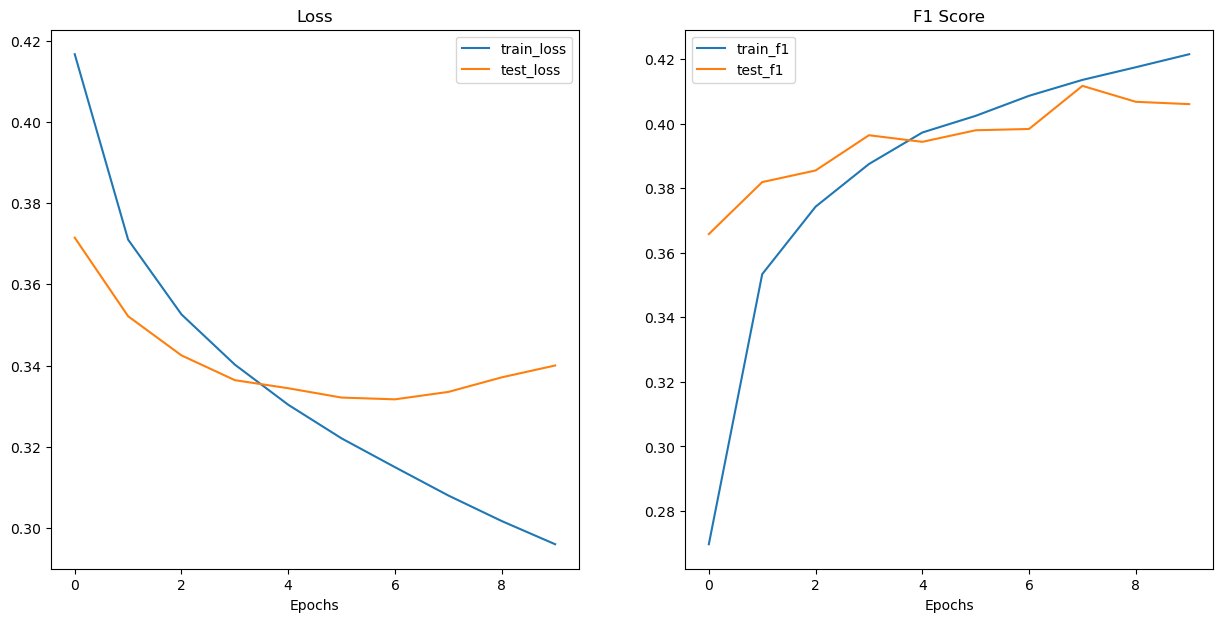

In [29]:
plot_loss_curves(model_1_results)